<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/rna-seq/ilk_analiz_volkan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# İlk analiz: knockout ne değiştirdi?

Bu defterde, Klf1 knockout ve yabani tip fare fetal karaciğerlerinin gen sayım tablosunu alıp tek bir soruya cevap arıyoruz: hangi genlerin ifadesi değişmiş? Sonunda elinizde bir volkan grafiği olacak.

Hiçbir şey kurmanız ve yüklemeniz gerekmiyor; veri, benim depomdan kendisi iniyor. Hücreleri yukarıdan aşağıya sırayla çalıştırın, beş dakikada bitiyor. Sayıların nereden geldiğini merak ederseniz projenin Veri sayfasına bakın; ben de aynı yoldan ürettim.

In [1]:
%pip install -q pydeseq2==0.5.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==

## 1. Tabloyu indiriyorum

Satırlar genler, sütunlar altı örnek: üç yabani tip (WT), üç knockout (KO). Sayılar, her örnekte o gene düşen okuma sayısı.

In [2]:
import pandas as pd

t = pd.read_csv('https://raw.githubusercontent.com/melissa-04/melisayla-biyoinformatik/main/data/rna-seq/sayim_tablosu.csv')
print(t.shape[0], 'gen ×', t.shape[1]-2, 'örnek')
t.head()

56065 gen × 6 örnek


,gen_id,gen_adi,WT_1,WT_2,WT_3,KO_1,KO_2,KO_3
0,ENSMUSG00000000001.5,Gnai3,1419,662,2800,2182,2872,2462
1,ENSMUSG00000000003.16,Pbsn,0,0,0,0,0,0
2,ENSMUSG00000000028.16,Cdc45,1654,1099,2770,1155,1891,1299
3,ENSMUSG00000000031.19,H19,26461,23546,74207,19488,32414,45889
4,ENSMUSG00000000037.18,Scml2,37,15,82,10,20,10


## 2. DESeq2'yi çalıştırıyorum

Az ifade edilen genleri eledikten sonra işi PyDESeq2'ye bırakıyorum: örnekler arası derinlik farkını dengeliyor, her gen için KO ile WT'yi karşılaştırıyor ve çoklu test düzeltmesi yapılmış bir p-değeri veriyor. Bu cümledeki her kavramın kendi rehberi var; burada sadece koşuyoruz.

In [3]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

adlar = dict(zip(t.gen_id, t.gen_adi))
sayim = t.set_index('gen_id').drop(columns='gen_adi').T
meta = pd.DataFrame({'genotip': ['WT']*3 + ['KO']*3}, index=sayim.index)
sayim = sayim[sayim.columns[sayim.sum(axis=0) >= 10]]

dds = DeseqDataSet(counts=sayim, metadata=meta, design='~genotip', quiet=True)
dds.deseq2()
st = DeseqStats(dds, contrast=['genotip', 'KO', 'WT'], quiet=True)
st.summary()

res = st.results_df.dropna(subset=['padj']).copy()
res['gen'] = [adlar[g] for g in res.index]
res = res.sort_values('padj')
print(len(res), 'gen test edildi')

17258 gen test edildi


## 3. Önce vicdan kontrolü: Klf1'in kendisi

log2FoldChange sütunu KO/WT oranının log2'si: -3 civarı bir değer, "knockoutta yaklaşık sekiz-dokuz kat düşük" demek. Sıfır değil; çünkü knockout lokusu çoğu zaman bozuk da olsa transkript üretmeye devam eder. Ardından en anlamlı on gene bakın: hepsi eritrosit genleri ve hepsi düşmüş.

In [4]:
print(res[res.gen == 'Klf1'][['gen','log2FoldChange','padj']].to_string(), '\n')
res.head(10)[['gen','log2FoldChange','padj']]

                        gen  log2FoldChange          padj
gen_id                                                   
ENSMUSG00000054191.10  Klf1       -3.144062  9.225652e-33 



,gen,log2FoldChange,padj
gen_id,,,
ENSMUSG00000034248.8,Slc25a37,-3.283441,1.616898e-140
ENSMUSG00000027075.17,Slc43a1,-5.249117,1.461794e-123
ENSMUSG00000022099.19,Dmtn,-7.444840,4.741981e-108
ENSMUSG00000025175.13,Fn3k,-8.886791,2.825565e-104
ENSMUSG00000023995.13,Tspo2,-4.954544,2.938841e-78
ENSMUSG00000056656.7,Apol8,-10.106820,5.680625e-77
ENSMUSG00000032028.16,Nxpe2,-7.977120,8.081128e-77
ENSMUSG00000050860.7,Phospho1,-5.181149,2.157557e-76
ENSMUSG00000027215.14,Cd82,-3.952021,9.902279e-71


## 4. Volkan grafiği

Her nokta bir gen. Yatay eksen değişimin yönü ve büyüklüğü, dikey eksen istatistiksel güven. Mor noktalar anlamlı olanlar (padj < 0.05 ve en az iki kat değişim), kırmızı nokta Klf1.

Anlamlı gen sayısı: 1388


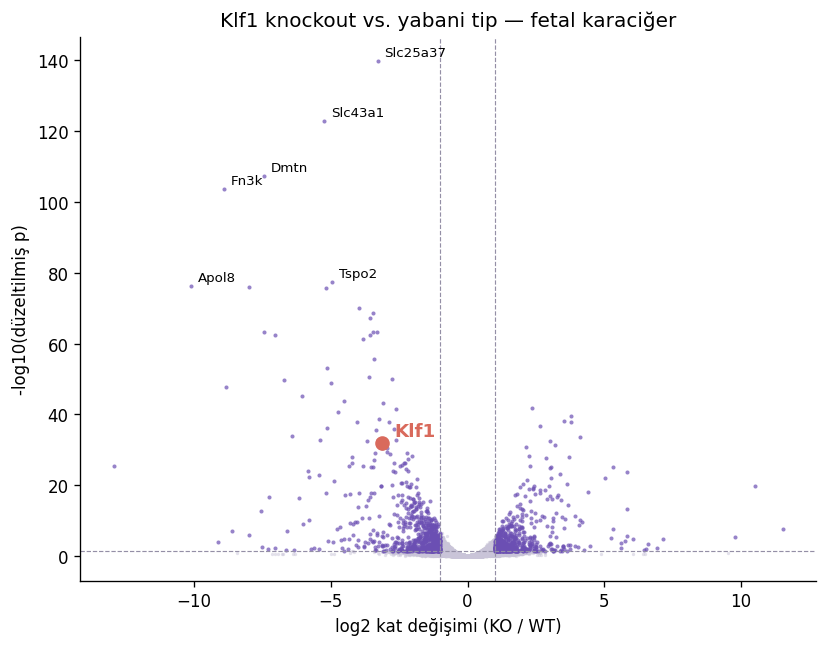

In [5]:
import numpy as np, matplotlib.pyplot as plt

anl = (res.padj < 0.05) & (res.log2FoldChange.abs() > 1)
print('Anlamlı gen sayısı:', int(anl.sum()))

fig, ax = plt.subplots(figsize=(7, 5.5), dpi=120)
x, y = res.log2FoldChange, -np.log10(res.padj)
ax.scatter(x[~anl], y[~anl], s=4, c='#C9C4D8', alpha=.5, lw=0)
ax.scatter(x[anl], y[anl], s=6, c='#6B4FB3', alpha=.7, lw=0)
k = res[res.gen == 'Klf1']
ax.scatter(k.log2FoldChange, -np.log10(k.padj), s=60, c='#D96A5C', zorder=5)
ax.annotate('Klf1', (k.log2FoldChange.iloc[0], -np.log10(k.padj.iloc[0])),
            xytext=(8, 4), textcoords='offset points', fontsize=11, fontweight='bold', color='#D96A5C')
for _, r in res.head(6).iterrows():
    if r.gen != 'Klf1':
        ax.annotate(r.gen, (r.log2FoldChange, -np.log10(r.padj)),
                    xytext=(4, 3), textcoords='offset points', fontsize=8)
ax.axhline(-np.log10(0.05), ls='--', lw=.7, c='#948FA6')
ax.axvline(1, ls='--', lw=.7, c='#948FA6'); ax.axvline(-1, ls='--', lw=.7, c='#948FA6')
ax.set_xlabel('log2 kat değişimi (KO / WT)')
ax.set_ylabel('-log10(düzeltilmiş p)')
ax.set_title('Klf1 knockout vs. yabani tip — fetal karaciğer')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## Kendin dene

Grafikte sol kanat sağdan kalabalık; KLF1 bir aktivatör olduğu için hedefleri onsuz düşüyor. Şimdi iki küçük görev: `res.head(10)` yerine `res[res.log2FoldChange > 0].head(10)` yazıp knockoutta *artan* genlere bakın; ne tür genler bunlar? Bir de merak ettiğiniz bir genin adını `res[res.gen == 'GenAdi']` ile arayın. Bulduklarınızı not edin; yolak analizi rehberinde bu listelere anlam vereceğiz.